# Customs 60 Classification Pipeline

This notebook performs:
- EDA on `train_60_custom_script (1).csv` and `test_60_custom_script (1).csv`
- Data cleaning and preprocessing
- Hyperparameter tuning with Stratified K-Fold
- Model training/evaluation for 3 setups:
  1. Binary classification (`NORMAL` vs `ATTACK`)
  2. Grouped 3-class classification (`NORMAL`, `DOS`, `ATTACK`)
  3. Full 12-class classification

Models used:
- Logistic Regression
- KNN
- Naive Bayes
- SVM
- Decision Tree
- Random Forest
- MLP
- AdaBoost
- Gradient Boosting

---
## 1. Imports & Configuration

Load all required libraries and set global constants used throughout the notebook.

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')


---
## 2. Load Data

Read the training and test CSV files and inspect their shapes and column structure.

In [7]:
# Load data
train_path = 'train_60_custom_script (1).csv'
test_path = 'test_60_custom_script (1).csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
print('')
print('Columns:', len(train_df.columns))
print('Last column (target expected):', repr(train_df.columns[-1]))


Train shape: (5904, 112)
Test shape : (2520, 112)

Columns: 112
Last column (target expected): 'Label'


---
## 3. Exploratory Data Analysis (EDA)

Inspect the class distribution across both the training and test sets. This helps identify any class imbalance that could affect model training and evaluation.

Unique classes in train: 12
Unique classes in test : 12

Train class counts:
Label
NORMAL           492
c_ci_na_1        492
c_ci_na_1_DoS    492
c_rd_na_1        492
c_rd_na_1_DoS    492
c_rp_na_1        492
c_rp_na_1_DoS    492
c_sc_na_1        492
c_sc_na_1_DoS    492
c_se_na_1        492
c_se_na_1_DoS    492
m_sp_na_1_DoS    492
Name: count, dtype: int64

Test class counts:
Label
NORMAL           210
c_ci_na_1        210
c_ci_na_1_DoS    210
c_rd_na_1        210
c_rd_na_1_DoS    210
c_rp_na_1        210
c_rp_na_1_DoS    210
c_sc_na_1        210
c_sc_na_1_DoS    210
c_se_na_1        210
c_se_na_1_DoS    210
m_sp_na_1_DoS    210
Name: count, dtype: int64


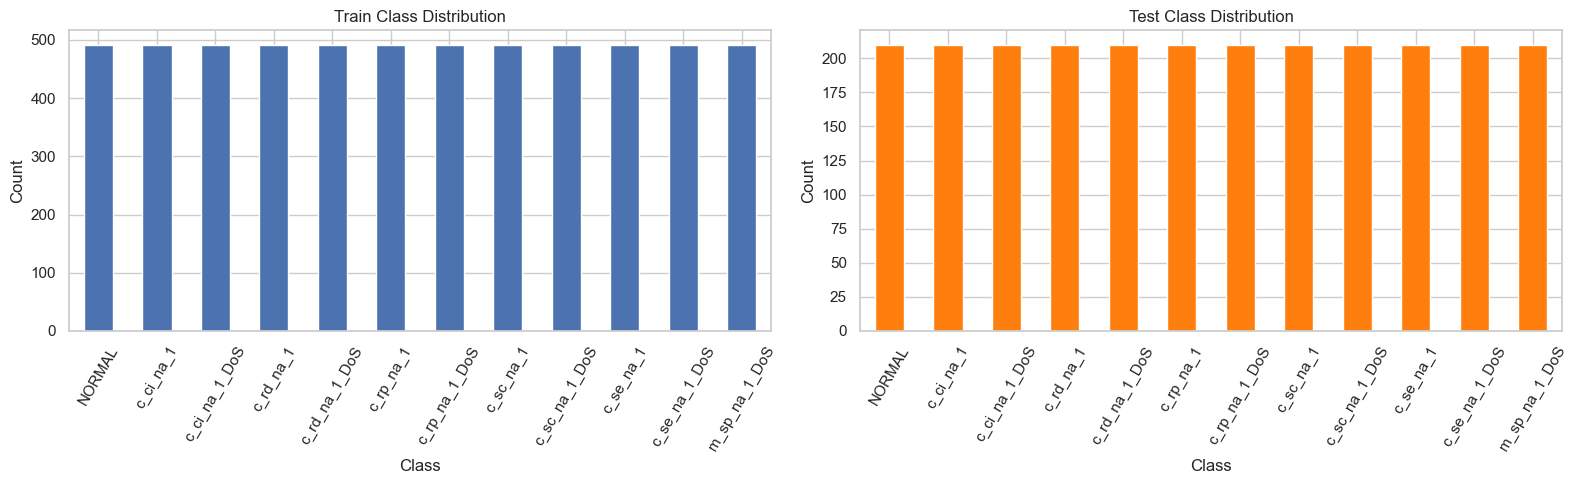

In [8]:
# Basic EDA
label_col = 'Label'

print('Unique classes in train:', train_df[label_col].nunique())
print('Unique classes in test :', test_df[label_col].nunique())
print('')
print('Train class counts:')
print(train_df[label_col].value_counts())
print('')
print('Test class counts:')
print(test_df[label_col].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
train_df[label_col].value_counts().plot(kind='bar', ax=axes[0], title='Train Class Distribution')
test_df[label_col].value_counts().plot(kind='bar', ax=axes[1], title='Test Class Distribution', color='tab:orange')
for ax in axes:
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()


---
## 4. Data Cleaning & Preprocessing

Clean both datasets by:
- Stripping whitespace from column names
- Removing duplicate rows
- Replacing `inf` values with `NaN` for safe imputation
- Coercing all feature columns to numeric types

Features and labels are then separated into `X` and `y`.

In [9]:
# Data quality checks and cleaning

def clean_dataframe(df, label_column='Label'):
    df = df.copy()

    # Strip accidental whitespace in column names
    df.columns = [c.strip() for c in df.columns]

    # Remove exact duplicate rows
    before = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    removed = before - len(df)

    # Split features/target
    X = df.drop(columns=[label_column])
    y = df[label_column].astype(str)

    # Replace inf with nan for robust imputation
    X = X.replace([np.inf, -np.inf], np.nan)

    # Keep numeric columns only (these datasets are numeric by design)
    X = X.apply(pd.to_numeric, errors='coerce')

    return X, y, removed

X_train_raw, y_full_train, removed_train = clean_dataframe(train_df, label_col)
X_test_raw, y_full_test, removed_test = clean_dataframe(test_df, label_col)

print(f'Duplicates removed - train: {removed_train}, test: {removed_test}')
print('Missing values in train features:', int(X_train_raw.isna().sum().sum()))
print('Missing values in test features :', int(X_test_raw.isna().sum().sum()))


Duplicates removed - train: 0, test: 1
Missing values in train features: 0
Missing values in test features : 0


---
## 5. Correlation Analysis

Compute a correlation snapshot to understand feature relationships. The top 15 features most correlated with the first feature are visualised as a heatmap.

Top 15 absolute correlations with 'flow idle time max'
flow IAT max                                     0.998707
flow IAT std                                     0.893093
fw IAT max                                       0.890563
flow idle time mean                              0.881052
fw total IEC104_U_Message packets                0.878672
flow IAT mean                                    0.792435
fw IAT std                                       0.764846
flow idle time variance                          0.689574
flow packet APDU length mean                     0.673456
flow idle time std                               0.631323
flow total IEC104_I_Message_SingleIOA packets    0.620203
flow packets APDU total length                   0.618617
bw packet APDU length min                        0.614346
flow ACK flag count                              0.613408
flow PSH flag count                              0.613408
Name: flow idle time max, dtype: float64


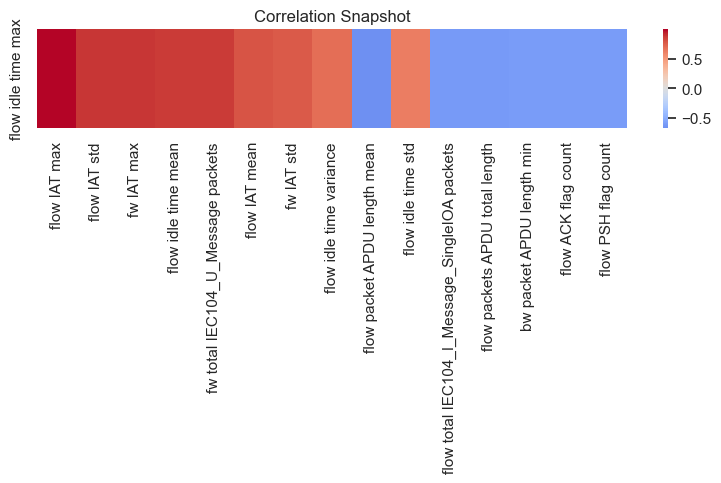

In [10]:
# Correlation snapshot (top absolute correlations with the first feature)
corr = X_train_raw.corr(numeric_only=True)
ref_col = X_train_raw.columns[0]

corr_ref = corr[ref_col].drop(ref_col).abs().sort_values(ascending=False).head(15)
print('Top 15 absolute correlations with', repr(ref_col))
print(corr_ref)

plt.figure(figsize=(8, 5))
sns.heatmap(corr.loc[[ref_col], corr_ref.index], cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Snapshot')
plt.tight_layout()
plt.show()


---
## 6. Target Label Transformations

Derive label variants for the three classification tasks from the original full 12-class labels:

- **Binary**: Collapses all non-NORMAL classes into a single `ATTACK` label.
- **3-Class**: Separates DoS-related attacks into a `DOS` group, keeps `NORMAL`, and groups the rest as `ATTACK`.
- **12-Class**: Uses the original labels as-is.

The distributions for each derived label set are printed for verification.

In [11]:
# Target transformations for three tasks

def to_binary_target(y):
    return np.where(y == 'NORMAL', 'NORMAL', 'ATTACK')


def to_three_class_target(y):
    y3 = []
    for cls in y:
        if cls == 'NORMAL':
            y3.append('NORMAL')
        elif 'DoS' in cls or 'DOS' in cls or 'dos' in cls:
            y3.append('DOS')
        else:
            y3.append('ATTACK')
    return np.array(y3)


y_binary_train = to_binary_target(y_full_train)
y_binary_test = to_binary_target(y_full_test)

y_three_train = to_three_class_target(y_full_train)
y_three_test = to_three_class_target(y_full_test)

print('Binary distribution (train):')
print(pd.Series(y_binary_train).value_counts())
print('')
print('3-class distribution (train):')
print(pd.Series(y_three_train).value_counts())
print('')
print('12-class distribution (train):')
print(y_full_train.value_counts())


Binary distribution (train):
ATTACK    5412
NORMAL     492
Name: count, dtype: int64

3-class distribution (train):
DOS       2952
ATTACK    2460
NORMAL     492
Name: count, dtype: int64

12-class distribution (train):
Label
NORMAL           492
c_ci_na_1        492
c_ci_na_1_DoS    492
c_rd_na_1        492
c_rd_na_1_DoS    492
c_rp_na_1        492
c_rp_na_1_DoS    492
c_sc_na_1        492
c_sc_na_1_DoS    492
c_se_na_1        492
c_se_na_1_DoS    492
m_sp_na_1_DoS    492
Name: count, dtype: int64


---
## 7. Shared Utilities: Model Spaces & Experiment Runner

Define the reusable components shared across all three setups:

- **`build_model_spaces()`** — Returns all 9 classifier pipelines with their hyperparameter search spaces.
- **`choose_best_k()`** — Selects the optimal number of folds for `StratifiedKFold` by evaluating a baseline Logistic Regression across candidate values of *k*.
- **`run_experiment()`** — Runs `RandomizedSearchCV` for each model, evaluates on the test set, and returns a results DataFrame and fitted estimators.

In [12]:
# Model definitions and search spaces

def build_model_spaces(random_state=42):
    spaces = {}

    spaces['Logistic Regression'] = (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=5000, random_state=random_state))
        ]),
        {
            'clf__C': np.logspace(-2, 2, 12),
            'clf__solver': ['lbfgs', 'liblinear'],
            'clf__class_weight': [None, 'balanced']
        }
    )

    spaces['KNN'] = (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('clf', KNeighborsClassifier())
        ]),
        {
            'clf__n_neighbors': list(range(3, 26, 2)),
            'clf__weights': ['uniform', 'distance'],
            'clf__metric': ['euclidean', 'manhattan']
        }
    )

    spaces['Naive Bayes'] = (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('clf', GaussianNB())
        ]),
        {
            'clf__var_smoothing': np.logspace(-12, -6, 12)
        }
    )

    spaces['SVM'] = (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('clf', SVC(random_state=random_state))
        ]),
        {
            'clf__C': np.logspace(-1, 2, 10),
            'clf__kernel': ['rbf', 'linear'],
            'clf__gamma': ['scale', 'auto']
        }
    )

    spaces['Decision Tree'] = (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('clf', DecisionTreeClassifier(random_state=random_state))
        ]),
        {
            'clf__max_depth': [None, 5, 10, 20, 30],
            'clf__min_samples_split': [2, 5, 10],
            'clf__min_samples_leaf': [1, 2, 4],
            'clf__criterion': ['gini', 'entropy']
        }
    )

    spaces['Random Forest'] = (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('clf', RandomForestClassifier(random_state=random_state, n_jobs=1))
        ]),
        {
            'clf__n_estimators': [100, 200, 300],
            'clf__max_depth': [None, 10, 20, 30],
            'clf__min_samples_split': [2, 5, 10],
            'clf__min_samples_leaf': [1, 2, 4],
            'clf__max_features': ['sqrt', 'log2', None]
        }
    )

    spaces['MLP'] = (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('clf', MLPClassifier(max_iter=500, early_stopping=False, random_state=random_state))
        ]),
        {
            'clf__hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
            'clf__activation': ['relu', 'tanh'],
            'clf__alpha': np.logspace(-5, -2, 8),
            'clf__learning_rate_init': [1e-3, 5e-4]
        }
    )

    spaces['AdaBoost'] = (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('clf', AdaBoostClassifier(random_state=random_state))
        ]),
        {
            'clf__n_estimators': [50, 100, 200, 300],
            'clf__learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
        }
    )

    spaces['Gradient Boosting'] = (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('clf', GradientBoostingClassifier(random_state=random_state))
        ]),
        {
            'clf__n_estimators': [100, 200, 300],
            'clf__learning_rate': [0.01, 0.05, 0.1],
            'clf__max_depth': [2, 3, 4],
            'clf__subsample': [0.8, 1.0]
        }
    )

    return spaces


def choose_best_k(X, y, k_values=(3, 5, 7, 10), random_state=42):
    baseline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=3000, random_state=random_state))
    ])

    rows = []
    for k in k_values:
        cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        scores = cross_val_score(baseline, X, y, scoring='f1_macro', cv=cv, n_jobs=1)
        rows.append({'k': k, 'cv_f1_macro_mean': scores.mean(), 'cv_f1_macro_std': scores.std()})

    k_df = pd.DataFrame(rows).sort_values('cv_f1_macro_mean', ascending=False).reset_index(drop=True)
    return int(k_df.loc[0, 'k']), k_df


In [13]:
# Training + tuning function

def run_experiment(X_train, y_train, X_test, y_test, task_name, n_iter=16, random_state=42):
    best_k, k_table = choose_best_k(X_train, y_train, random_state=random_state)
    print('')
    print(f'===== {task_name} =====')
    print('Best k for StratifiedKFold:', best_k)
    print(k_table)

    cv = StratifiedKFold(n_splits=best_k, shuffle=True, random_state=random_state)
    model_spaces = build_model_spaces(random_state=random_state)

    results = []
    best_estimators = {}

    for model_name, (pipeline, param_space) in model_spaces.items():
        print('')
        print(f'Tuning: {model_name}')

        search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_space,
            n_iter=n_iter,
            scoring='f1_macro',
            n_jobs=1,
            cv=cv,
            random_state=random_state,
            verbose=0,
            refit=True
        )

        search.fit(X_train, y_train)
        y_pred = search.best_estimator_.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1m = f1_score(y_test, y_pred, average='macro', zero_division=0)
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)

        results.append({
            'Task': task_name,
            'Model': model_name,
            'Best_K': best_k,
            'Best_CV_F1_Macro': search.best_score_,
            'Test_Accuracy': acc,
            'Test_F1_Macro': f1m,
            'Test_Precision_Macro': prec,
            'Test_Recall_Macro': rec,
            'Best_Params': search.best_params_
        })

        best_estimators[model_name] = search.best_estimator_
        print(f'CV F1_macro: {search.best_score_:.4f} | Test Acc: {acc:.4f} | Test F1_macro: {f1m:.4f}')

    result_df = pd.DataFrame(results).sort_values(['Test_F1_Macro', 'Test_Accuracy'], ascending=False).reset_index(drop=True)
    return result_df, best_estimators, best_k


---
## 8. Setup 1 — Binary Classification: NORMAL vs ATTACK

This is the simplest setup. All traffic is classified into one of two categories:
- **NORMAL** — benign traffic
- **ATTACK** — any type of malicious/anomalous traffic

Binary classification is a useful baseline and tends to yield the highest F1 scores since the decision boundary is less complex. Each of the 9 models is tuned via `RandomizedSearchCV` with the best-selected `StratifiedKFold` *k*.

In [14]:
# Setup 1: Binary Classification (NORMAL vs ATTACK)
binary_results, binary_estimators, binary_k = run_experiment(
    X_train_raw, y_binary_train, X_test_raw, y_binary_test,
    task_name='Binary (NORMAL vs ATTACK)', n_iter=14
)

print('')
print('Top 3 models (Binary):')
print(binary_results[['Model', 'Best_K', 'Test_Accuracy', 'Test_F1_Macro']].head(3))



===== Binary (NORMAL vs ATTACK) =====
Best k for StratifiedKFold: 3
    k  cv_f1_macro_mean  cv_f1_macro_std
0   3               1.0              0.0
1   5               1.0              0.0
2   7               1.0              0.0
3  10               1.0              0.0

Tuning: Logistic Regression
CV F1_macro: 1.0000 | Test Acc: 1.0000 | Test F1_macro: 1.0000

Tuning: KNN
CV F1_macro: 1.0000 | Test Acc: 1.0000 | Test F1_macro: 1.0000

Tuning: Naive Bayes
CV F1_macro: 0.9951 | Test Acc: 0.9976 | Test F1_macro: 0.9923

Tuning: SVM
CV F1_macro: 1.0000 | Test Acc: 1.0000 | Test F1_macro: 1.0000

Tuning: Decision Tree
CV F1_macro: 0.9978 | Test Acc: 0.9988 | Test F1_macro: 0.9961

Tuning: Random Forest
CV F1_macro: 1.0000 | Test Acc: 1.0000 | Test F1_macro: 1.0000

Tuning: MLP
CV F1_macro: 1.0000 | Test Acc: 0.9996 | Test F1_macro: 0.9987

Tuning: AdaBoost
CV F1_macro: 1.0000 | Test Acc: 0.9992 | Test F1_macro: 0.9974

Tuning: Gradient Boosting
CV F1_macro: 0.9983 | Test Acc: 0.9988 | T

### Results — Binary Classification

The table below shows all models ranked by Test F1 Macro for the binary task.

In [15]:
binary_results[['Task', 'Model', 'Best_K', 'Best_CV_F1_Macro', 'Test_Accuracy', 'Test_F1_Macro', 'Test_Precision_Macro', 'Test_Recall_Macro']]


,Task,Model,Best_K,Best_CV_F1_Macro,Test_Accuracy,Test_F1_Macro,Test_Precision_Macro,Test_Recall_Macro
0,Binary (NORMAL vs ATTACK),Logistic Regression,3,1.000000,1.000000,1.000000,1.000000,1.000000
1,Binary (NORMAL vs ATTACK),KNN,3,1.000000,1.000000,1.000000,1.000000,1.000000
2,Binary (NORMAL vs ATTACK),SVM,3,1.000000,1.000000,1.000000,1.000000,1.000000
3,Binary (NORMAL vs ATTACK),Random Forest,3,1.000000,1.000000,1.000000,1.000000,1.000000
4,Binary (NORMAL vs ATTACK),MLP,3,1.000000,0.999603,0.998704,0.997630,0.999783
5,Binary (NORMAL vs ATTACK),AdaBoost,3,1.000000,0.999206,0.997403,0.997403,0.997403
6,Binary (NORMAL vs ATTACK),Decision Tree,3,0.997777,0.998809,0.996095,0.997175,0.995022
7,Binary (NORMAL vs ATTACK),Gradient Boosting,3,0.998329,0.998809,0.996095,0.997175,0.995022
8,Binary (NORMAL vs ATTACK),Naive Bayes,3,0.995109,0.997618,0.992307,0.986111,0.998701


---
## 9. Setup 2 — Grouped 3-Class Classification: NORMAL / DOS / ATTACK

This setup adds a layer of granularity by separating DoS-related attacks from general attacks:
- **NORMAL** — benign traffic
- **DOS** — Denial-of-Service attack variants (e.g., DoS Slowloris, DoS Hulk)
- **ATTACK** — all other attack types

This grouping is meaningful because DoS attacks have distinct traffic patterns (high volume, connection exhaustion) compared to other attacks such as port scans or brute-force attempts. Separating them tests whether models can distinguish these behavioural differences.

In [16]:
# Setup 2: Grouped 3-Class Classification (NORMAL / DOS / ATTACK)
three_results, three_estimators, three_k = run_experiment(
    X_train_raw, y_three_train, X_test_raw, y_three_test,
    task_name='Grouped 3-Class (NORMAL / DOS / ATTACK)', n_iter=14
)

print('')
print('Top 3 models (3-Class):')
print(three_results[['Model', 'Best_K', 'Test_Accuracy', 'Test_F1_Macro']].head(3))



===== Grouped 3-Class (NORMAL / DOS / ATTACK) =====
Best k for StratifiedKFold: 5
    k  cv_f1_macro_mean  cv_f1_macro_std
0   5          0.766145         0.012414
1  10          0.766058         0.014865
2   7          0.765102         0.008747
3   3          0.763610         0.012880

Tuning: Logistic Regression
CV F1_macro: 0.7685 | Test Acc: 0.6780 | Test F1_macro: 0.7638

Tuning: KNN
CV F1_macro: 0.7719 | Test Acc: 0.7007 | Test F1_macro: 0.7810

Tuning: Naive Bayes
CV F1_macro: 0.6635 | Test Acc: 0.5816 | Test F1_macro: 0.6545

Tuning: SVM
CV F1_macro: 0.7683 | Test Acc: 0.6832 | Test F1_macro: 0.7681

Tuning: Decision Tree
CV F1_macro: 0.7809 | Test Acc: 0.7733 | Test F1_macro: 0.8337

Tuning: Random Forest
CV F1_macro: 0.7962 | Test Acc: 0.7654 | Test F1_macro: 0.8287

Tuning: MLP
CV F1_macro: 0.7810 | Test Acc: 0.7011 | Test F1_macro: 0.7816

Tuning: AdaBoost
CV F1_macro: 0.6815 | Test Acc: 0.8452 | Test F1_macro: 0.8843

Tuning: Gradient Boosting
CV F1_macro: 0.7914 | Test A

### Results — 3-Class Classification

The table below shows all models ranked by Test F1 Macro for the 3-class task.

In [17]:
three_results[['Task', 'Model', 'Best_K', 'Best_CV_F1_Macro', 'Test_Accuracy', 'Test_F1_Macro', 'Test_Precision_Macro', 'Test_Recall_Macro']]


,Task,Model,Best_K,Best_CV_F1_Macro,Test_Accuracy,Test_F1_Macro,Test_Precision_Macro,Test_Recall_Macro
0,Grouped 3-Class (NORMAL / DOS / ATTACK),AdaBoost,5,0.681478,0.845177,0.884264,0.885556,0.883137
1,Grouped 3-Class (NORMAL / DOS / ATTACK),Decision Tree,5,0.780905,0.773323,0.833675,0.842676,0.839910
2,Grouped 3-Class (NORMAL / DOS / ATTACK),Gradient Boosting,5,0.791444,0.772529,0.832003,0.848378,0.839903
3,Grouped 3-Class (NORMAL / DOS / ATTACK),Random Forest,5,0.796227,0.765383,0.828678,0.844271,0.837308
4,Grouped 3-Class (NORMAL / DOS / ATTACK),MLP,5,0.780991,0.701072,0.781555,0.792213,0.787719
5,Grouped 3-Class (NORMAL / DOS / ATTACK),KNN,5,0.771943,0.700675,0.780985,0.780830,0.781293
6,Grouped 3-Class (NORMAL / DOS / ATTACK),SVM,5,0.768288,0.683208,0.768125,0.768820,0.768163
7,Grouped 3-Class (NORMAL / DOS / ATTACK),Logistic Regression,5,0.768497,0.678047,0.763842,0.763021,0.764884
8,Grouped 3-Class (NORMAL / DOS / ATTACK),Naive Bayes,5,0.663468,0.581580,0.654502,0.791515,0.717934


---
## 10. Setup 3 — Full 12-Class Classification

This is the most challenging setup, using the original fine-grained labels across all 12 traffic classes (NORMAL + 11 attack subtypes).

This tests the models' ability to distinguish between attack subtypes that may share overlapping feature profiles — for example, different DoS variants or reconnaissance attacks. Macro F1 is a particularly informative metric here as it weights each class equally, penalising models that ignore minority attack types.

In [18]:
# Setup 3: Full 12-Class Classification
full_results, full_estimators, full_k = run_experiment(
    X_train_raw, y_full_train, X_test_raw, y_full_test,
    task_name='Full 12-Class', n_iter=14
)

print('')
print('Top 3 models (12-Class):')
print(full_results[['Model', 'Best_K', 'Test_Accuracy', 'Test_F1_Macro']].head(3))



===== Full 12-Class =====
Best k for StratifiedKFold: 3
    k  cv_f1_macro_mean  cv_f1_macro_std
0   3          0.554801         0.011410
1  10          0.551447         0.024964
2   5          0.548550         0.015806
3   7          0.547503         0.018619

Tuning: Logistic Regression
CV F1_macro: 0.5610 | Test Acc: 0.5490 | Test F1_macro: 0.5332

Tuning: KNN
CV F1_macro: 0.5621 | Test Acc: 0.5574 | Test F1_macro: 0.5513

Tuning: Naive Bayes
CV F1_macro: 0.4537 | Test Acc: 0.4923 | Test F1_macro: 0.4099

Tuning: SVM
CV F1_macro: 0.5648 | Test Acc: 0.5431 | Test F1_macro: 0.5349

Tuning: Decision Tree
CV F1_macro: 0.5859 | Test Acc: 0.5756 | Test F1_macro: 0.5556

Tuning: Random Forest
CV F1_macro: 0.6109 | Test Acc: 0.5987 | Test F1_macro: 0.5818

Tuning: MLP
CV F1_macro: 0.5769 | Test Acc: 0.5649 | Test F1_macro: 0.5576

Tuning: AdaBoost
CV F1_macro: 0.4347 | Test Acc: 0.5066 | Test F1_macro: 0.4151

Tuning: Gradient Boosting
CV F1_macro: 0.6124 | Test Acc: 0.5593 | Test F1_macro

### Results — 12-Class Classification

The table below shows all models ranked by Test F1 Macro for the full 12-class task.

In [19]:
full_results[['Task', 'Model', 'Best_K', 'Best_CV_F1_Macro', 'Test_Accuracy', 'Test_F1_Macro', 'Test_Precision_Macro', 'Test_Recall_Macro']]


,Task,Model,Best_K,Best_CV_F1_Macro,Test_Accuracy,Test_F1_Macro,Test_Precision_Macro,Test_Recall_Macro
0,Full 12-Class,Random Forest,3,0.610937,0.598650,0.581773,0.627999,0.598492
1,Full 12-Class,MLP,3,0.576887,0.564907,0.557619,0.579383,0.564770
2,Full 12-Class,Decision Tree,3,0.585920,0.575625,0.555613,0.609760,0.575433
3,Full 12-Class,KNN,3,0.562112,0.557364,0.551298,0.552988,0.557253
4,Full 12-Class,Gradient Boosting,3,0.612377,0.559349,0.543104,0.580979,0.559201
5,Full 12-Class,SVM,3,0.564847,0.543073,0.534906,0.555186,0.542946
6,Full 12-Class,Logistic Regression,3,0.560989,0.549027,0.533155,0.553119,0.548880
7,Full 12-Class,AdaBoost,3,0.434735,0.506550,0.415133,0.466956,0.506349
8,Full 12-Class,Naive Bayes,3,0.453724,0.492259,0.409858,0.441737,0.492098


---
## 11. Cross-Setup Comparison

Combine results from all three setups to compare model performance across tasks. The bar chart visualises Test F1 Macro per model and task, making it easy to spot which models degrade most as classification complexity increases.

Top models per task (by Test_F1_Macro):
                                       Task                Model  Best_K  \
0                 Binary (NORMAL vs ATTACK)  Logistic Regression       3   
1                 Binary (NORMAL vs ATTACK)                  KNN       3   
2                 Binary (NORMAL vs ATTACK)                  SVM       3   
18                            Full 12-Class        Random Forest       3   
19                            Full 12-Class                  MLP       3   
20                            Full 12-Class        Decision Tree       3   
9   Grouped 3-Class (NORMAL / DOS / ATTACK)             AdaBoost       5   
10  Grouped 3-Class (NORMAL / DOS / ATTACK)        Decision Tree       5   
11  Grouped 3-Class (NORMAL / DOS / ATTACK)    Gradient Boosting       5   

    Test_Accuracy  Test_F1_Macro  
0        1.000000       1.000000  
1        1.000000       1.000000  
2        1.000000       1.000000  
18       0.598650       0.581773  
19       0.564907       

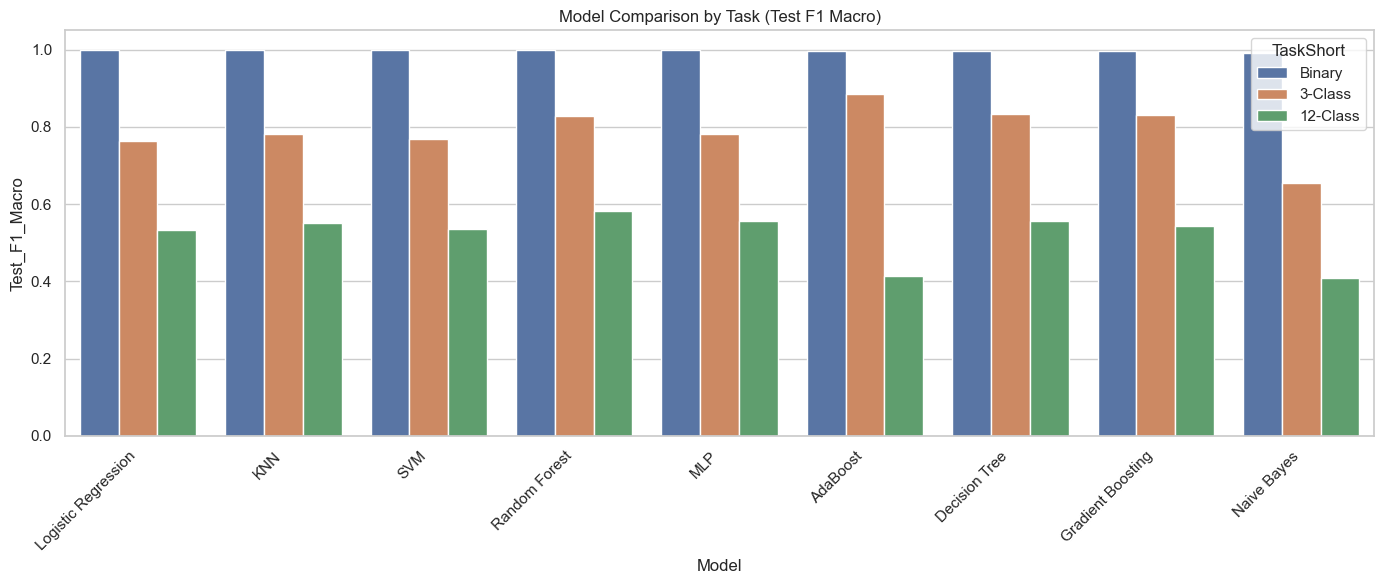

,Task,Model,Best_K,Best_CV_F1_Macro,Test_Accuracy,Test_F1_Macro,Test_Precision_Macro,Test_Recall_Macro
0,Binary (NORMAL vs ATTACK),Logistic Regression,3,1.000000,1.000000,1.000000,1.000000,1.000000
1,Binary (NORMAL vs ATTACK),KNN,3,1.000000,1.000000,1.000000,1.000000,1.000000
2,Binary (NORMAL vs ATTACK),SVM,3,1.000000,1.000000,1.000000,1.000000,1.000000
3,Binary (NORMAL vs ATTACK),Random Forest,3,1.000000,1.000000,1.000000,1.000000,1.000000
4,Binary (NORMAL vs ATTACK),MLP,3,1.000000,0.999603,0.998704,0.997630,0.999783
5,Binary (NORMAL vs ATTACK),AdaBoost,3,1.000000,0.999206,0.997403,0.997403,0.997403
6,Binary (NORMAL vs ATTACK),Decision Tree,3,0.997777,0.998809,0.996095,0.997175,0.995022
7,Binary (NORMAL vs ATTACK),Gradient Boosting,3,0.998329,0.998809,0.996095,0.997175,0.995022
8,Binary (NORMAL vs ATTACK),Naive Bayes,3,0.995109,0.997618,0.992307,0.986111,0.998701
18,Full 12-Class,Random Forest,3,0.610937,0.598650,0.581773,0.627999,0.598492


In [20]:
# Combine all results
all_results = pd.concat([binary_results, three_results, full_results], ignore_index=True)

print('Top models per task (by Test_F1_Macro):')
print(
    all_results
    .sort_values(['Task', 'Test_F1_Macro'], ascending=[True, False])
    .groupby('Task')
    .head(3)[['Task', 'Model', 'Best_K', 'Test_Accuracy', 'Test_F1_Macro']]
)

# Visual comparison
plt.figure(figsize=(14, 6))
plot_df = all_results.copy()
plot_df['TaskShort'] = plot_df['Task'].map({
    'Binary (NORMAL vs ATTACK)': 'Binary',
    'Grouped 3-Class (NORMAL / DOS / ATTACK)': '3-Class',
    'Full 12-Class': '12-Class'
})

sns.barplot(data=plot_df, x='Model', y='Test_F1_Macro', hue='TaskShort')
plt.xticks(rotation=45, ha='right')
plt.title('Model Comparison by Task (Test F1 Macro)')
plt.tight_layout()
plt.show()

all_results[
    ['Task', 'Model', 'Best_K', 'Best_CV_F1_Macro', 'Test_Accuracy',
     'Test_F1_Macro', 'Test_Precision_Macro', 'Test_Recall_Macro']
].sort_values(['Task', 'Test_F1_Macro'], ascending=[True, False])


---
## 12. Best Model Reports

For the best-performing model in each setup, generate:
- A **confusion matrix** heatmap showing where misclassifications occur
- A full **classification report** with per-class precision, recall, and F1

These detailed breakdowns are useful for diagnosing weaknesses — for example, attack subtypes that are consistently confused with one another.


===== Best Model for Binary =====
Model: Logistic Regression
Best K: 3
Test Accuracy: 1.0
Test F1 Macro: 1.0


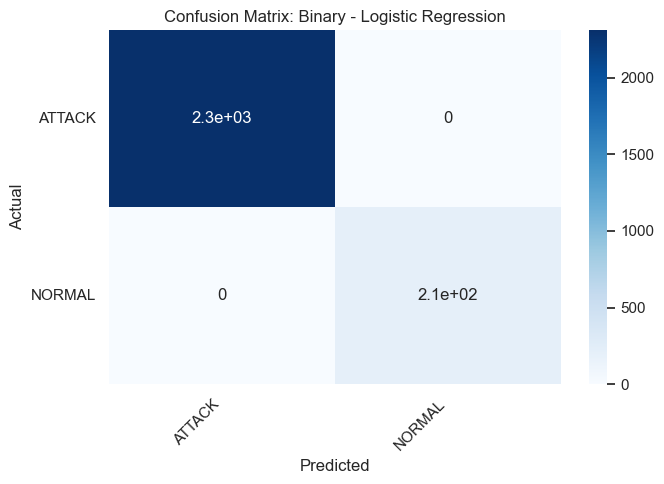

              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00      2309
      NORMAL       1.00      1.00      1.00       210

    accuracy                           1.00      2519
   macro avg       1.00      1.00      1.00      2519
weighted avg       1.00      1.00      1.00      2519


===== Best Model for 3-Class =====
Model: AdaBoost
Best K: 5
Test Accuracy: 0.8452
Test F1 Macro: 0.8843


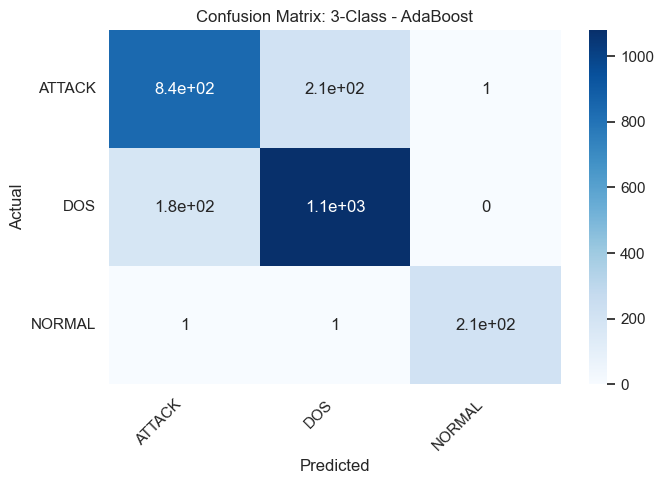

              precision    recall  f1-score   support

      ATTACK       0.82      0.80      0.81      1050
         DOS       0.84      0.86      0.85      1259
      NORMAL       1.00      0.99      0.99       210

    accuracy                           0.85      2519
   macro avg       0.89      0.88      0.88      2519
weighted avg       0.85      0.85      0.85      2519


===== Best Model for 12-Class =====
Model: Random Forest
Best K: 3
Test Accuracy: 0.5987
Test F1 Macro: 0.5818


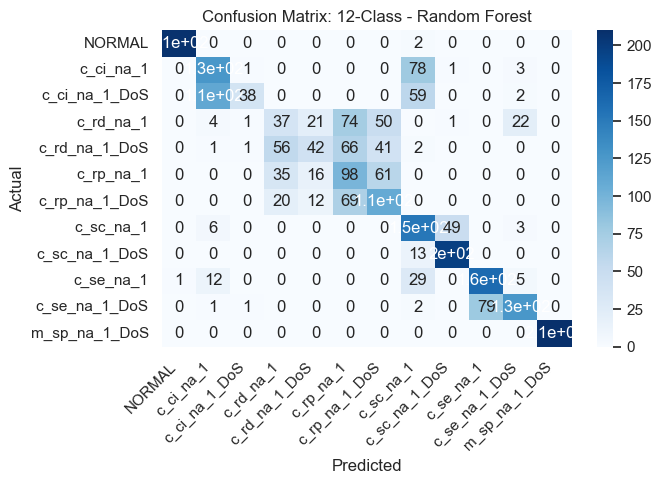

               precision    recall  f1-score   support

       NORMAL       1.00      0.99      0.99       210
    c_ci_na_1       0.48      0.60      0.54       210
c_ci_na_1_DoS       0.90      0.18      0.30       210
    c_rd_na_1       0.25      0.18      0.21       210
c_rd_na_1_DoS       0.46      0.20      0.28       209
    c_rp_na_1       0.32      0.47      0.38       210
c_rp_na_1_DoS       0.42      0.52      0.46       210
    c_sc_na_1       0.45      0.72      0.56       210
c_sc_na_1_DoS       0.79      0.94      0.86       210
    c_se_na_1       0.67      0.78      0.72       210
c_se_na_1_DoS       0.78      0.60      0.68       210
m_sp_na_1_DoS       1.00      1.00      1.00       210

     accuracy                           0.60      2519
    macro avg       0.63      0.60      0.58      2519
 weighted avg       0.63      0.60      0.58      2519



In [21]:
# Detailed reports for best model in each task

def show_best_model_report(task_name, result_df, estimators, X_test, y_test):
    best_row = result_df.sort_values('Test_F1_Macro', ascending=False).iloc[0]
    model_name = best_row['Model']
    model = estimators[model_name]
    y_pred = model.predict(X_test)

    print('')
    print(f'===== Best Model for {task_name} =====')
    print('Model:', model_name)
    print('Best K:', int(best_row['Best_K']))
    print('Test Accuracy:', round(best_row['Test_Accuracy'], 4))
    print('Test F1 Macro:', round(best_row['Test_F1_Macro'], 4))

    labels = sorted(pd.Series(y_test).unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix: {task_name} - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print(classification_report(y_test, y_pred, zero_division=0))


show_best_model_report('Binary', binary_results, binary_estimators, X_test_raw, y_binary_test)
show_best_model_report('3-Class', three_results, three_estimators, X_test_raw, y_three_test)
show_best_model_report('12-Class', full_results, full_estimators, X_test_raw, y_full_test)


---
## 13. Save Results

Export the full model comparison summary across all three setups to a CSV file for further analysis or reporting.

In [22]:
# Save experiment summary
summary_path = 'model_comparison_summary.csv'
all_results.to_csv(summary_path, index=False)
print('Saved:', summary_path)
all_results.head()


Saved: model_comparison_summary.csv


,Task,Model,Best_K,Best_CV_F1_Macro,Test_Accuracy,Test_F1_Macro,Test_Precision_Macro,Test_Recall_Macro,Best_Params
0,Binary (NORMAL vs ATTACK),Logistic Regression,3,1.0,1.000000,1.000000,1.00000,1.000000,"{'clf__solver': 'lbfgs', 'clf__class_weight': ..."
1,Binary (NORMAL vs ATTACK),KNN,3,1.0,1.000000,1.000000,1.00000,1.000000,"{'clf__weights': 'distance', 'clf__n_neighbors..."
2,Binary (NORMAL vs ATTACK),SVM,3,1.0,1.000000,1.000000,1.00000,1.000000,"{'clf__kernel': 'linear', 'clf__gamma': 'auto'..."
3,Binary (NORMAL vs ATTACK),Random Forest,3,1.0,1.000000,1.000000,1.00000,1.000000,"{'clf__n_estimators': 100, 'clf__min_samples_s..."
4,Binary (NORMAL vs ATTACK),MLP,3,1.0,0.999603,0.998704,0.99763,0.999783,"{'clf__learning_rate_init': 0.0005, 'clf__hidd..."
